# Lane Detection: Mask White Pixels in a Grayscale Image

This notebook runs a simple **colour selection** step for lane detection. Lane markings are usually the brightest objects on the road, so keeping only the near-white pixels of a grayscale image isolates them from the asphalt, grass and sky.

**What it does:**
1. Loads the colour road image `image_lane_c.jpg`.
2. Converts it to **grayscale** (one brightness value per pixel, 0 = black and 255 = white).
3. Applies a **brightness threshold**: pixels at or above `WHITE_THRESHOLD` are kept and all others are set to black.
4. Shows the original, the grayscale image and the white mask side by side.
5. Plots a brightness histogram with the threshold marked.
6. Compares several thresholds (`COMPARE_THRESHOLDS`: 250, 240, 230) with a reusable function that shows each mask next to its histogram.
7. Saves the mask for `WHITE_THRESHOLD` as `image_lane_white_mask.jpg` and each comparison mask as `image_lane_white_mask_<threshold>.jpg`.

**Changes from the original lecture code (Lecture 4.5):**
- The original loaded the image with `matplotlib.image.imread` (**RGB** order) and then converted it with `cv2.COLOR_BGR2GRAY`. That swaps the red and blue weights. This version loads with `cv2.imread` (BGR), so `COLOR_BGR2GRAY` is correct.
- The threshold is a named constant instead of a magic number.
- The mask is built with a boolean NumPy expression, so the input image is never modified in place.
- Missing files and failed saves raise clear errors.

## 1. Imports

- `cv2` (OpenCV): image I/O and colour conversion
- `matplotlib`: displaying images
- `numpy`: array operations
- `pathlib`: file paths that work on any OS

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Configuration

`WHITE_THRESHOLD` sets how bright a pixel must be to count as "white". The lecture used 250. We use 240 here, because the threshold comparison in section 7 shows it is the best value for this image. Lower values keep more pixels, including bright asphalt and sky. Higher values keep only the brightest lane paint.

`COMPARE_THRESHOLDS` lists the thresholds compared in section 7.

In [2]:
INPUT_PATH = Path("image_lane_c.jpg")
OUTPUT_PATH = INPUT_PATH.with_name("image_lane_white_mask.jpg")

WHITE_THRESHOLD = 240  # 0-255: minimum brightness to count as white
COMPARE_THRESHOLDS = (250, 240, 230)  # thresholds compared side by side in section 7

## 3. Load the image and convert it to grayscale

`cv2.imread` returns `None` instead of raising an error when a file is missing, so we check for that.

> ⚠️ OpenCV loads images in **BGR** order. We use `COLOR_BGR2GRAY` for the grayscale conversion and `COLOR_BGR2RGB` only for display with Matplotlib.

In [3]:
image_bgr = cv2.imread(str(INPUT_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {INPUT_PATH.resolve()}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

height, width = image_gray.shape
print(f"Image size: {width}x{height} px")
print(f"Grayscale:  shape={image_gray.shape}, dtype={image_gray.dtype}")

Image size: 960x540 px
Grayscale:  shape=(540, 960), dtype=uint8


## 4. Mask the white pixels

We build a boolean mask that is `True` wherever the brightness is at least `WHITE_THRESHOLD`. `np.where` then keeps those pixels at their original value and sets all others to 0 (black).

This does the same job as the lecture's `image_copy[image_copy < 250] = 0`, but it doesn't need a manual copy and it leaves `image_gray` unchanged.

In [4]:
white_mask = image_gray >= WHITE_THRESHOLD
image_white = np.where(white_mask, image_gray, 0).astype(np.uint8)

kept = int(white_mask.sum())
print(f"Threshold: {WHITE_THRESHOLD}")
print(f"White pixels kept: {kept:,} of {white_mask.size:,} ({kept / white_mask.size:.2%})")

Threshold: 240
White pixels kept: 2,578 of 518,400 (0.50%)


## 5. Compare the results

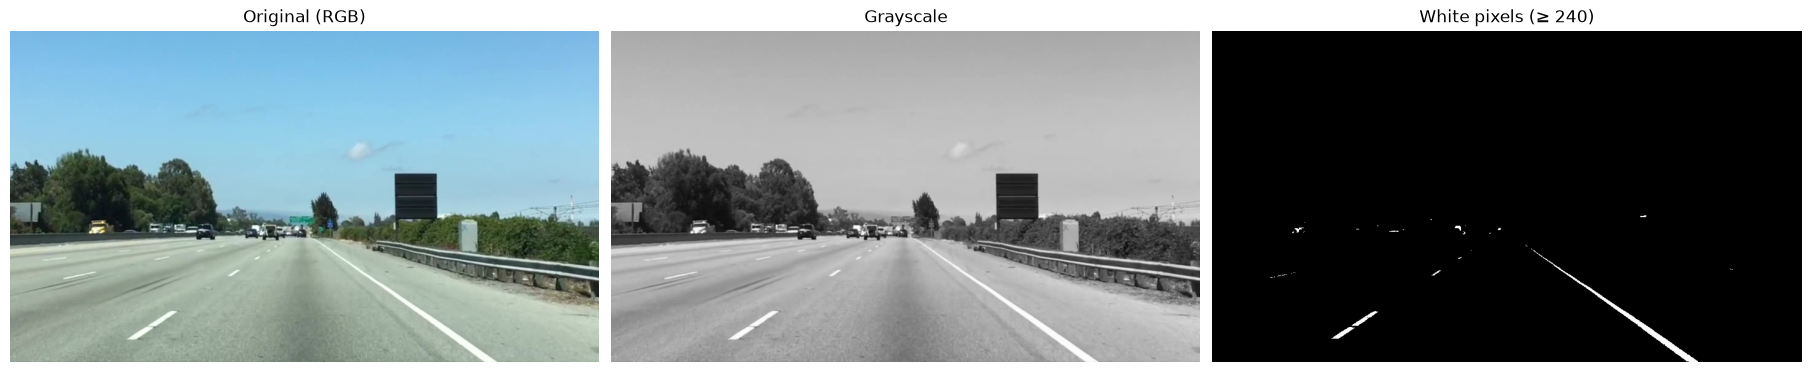

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), layout="constrained")

axes[0].imshow(image_rgb)
axes[0].set_title("Original (RGB)")

axes[1].imshow(image_gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Grayscale")

axes[2].imshow(image_white, cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"White pixels (≥ {WHITE_THRESHOLD})")

for ax in axes:
    ax.axis("off")

plt.show()

## 6. Brightness histogram

The histogram shows how the grayscale values are distributed. The dashed line marks the threshold, and everything to the right of it is kept. It helps you choose a good `WHITE_THRESHOLD` for other images.

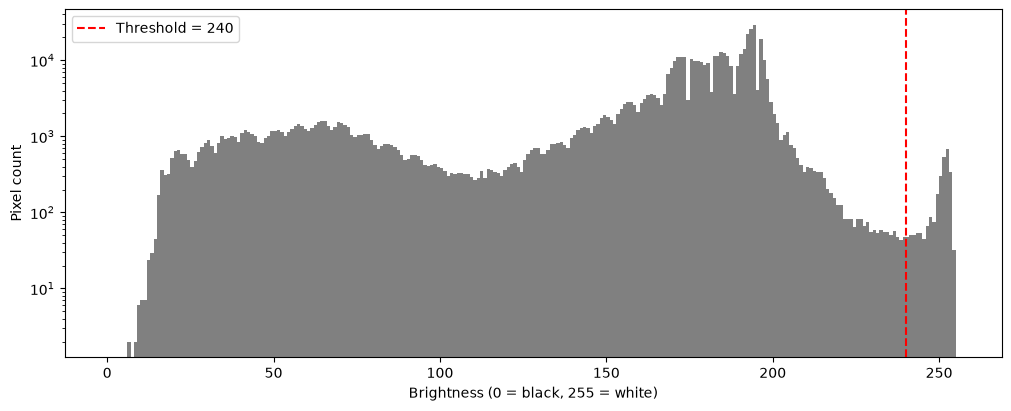

In [6]:
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")

ax.hist(image_gray.ravel(), bins=256, range=(0, 256), color="gray")
ax.axvline(WHITE_THRESHOLD, color="red", linestyle="--", label=f"Threshold = {WHITE_THRESHOLD}")
ax.set_xlabel("Brightness (0 = black, 255 = white)")
ax.set_ylabel("Pixel count")
ax.set_yscale("log")
ax.legend()

plt.show()

## 7. Compare several thresholds

A single threshold is a trade-off. If it's too high, faint or shaded lane paint disappears. If it's too low, bright asphalt, sky and cars leak into the mask.

`compare_thresholds` gives one row per threshold:
- **left:** the white-pixel mask for that threshold
- **right:** the brightness histogram with the kept range (≥ threshold) shaded

It returns a dictionary that maps each threshold to its mask image, so you can reuse the masks later.

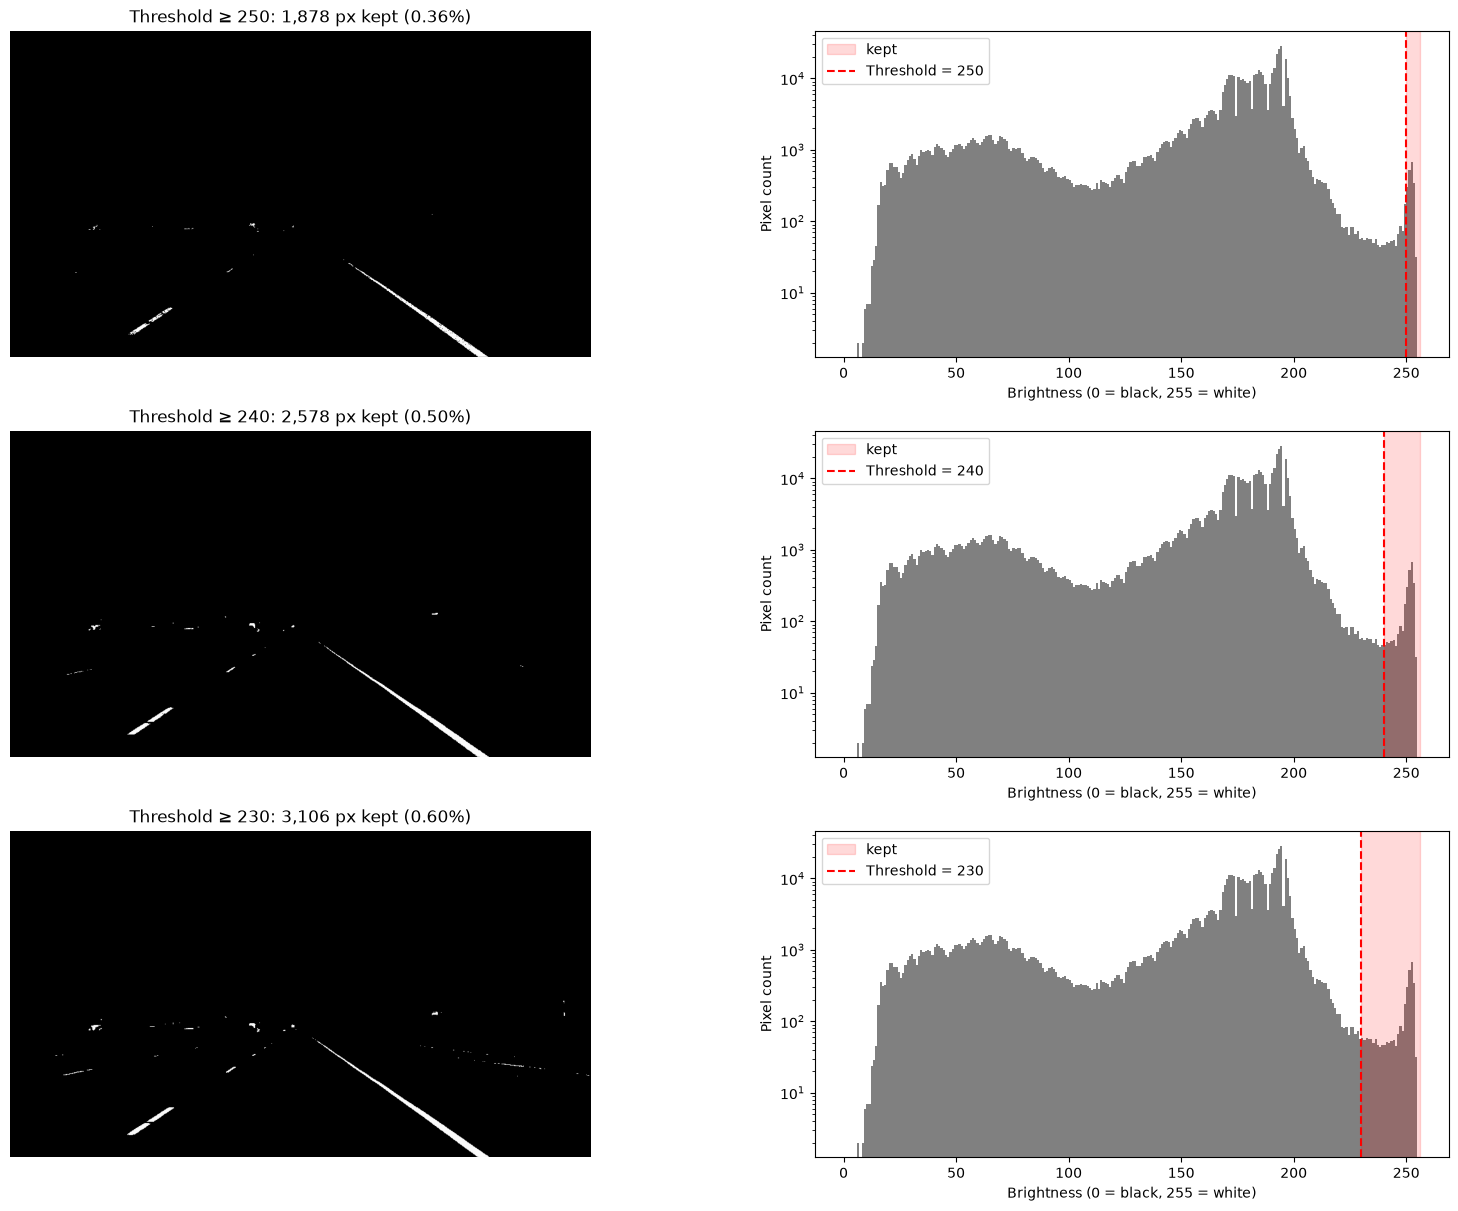

In [7]:
def compare_thresholds(
    image_gray: np.ndarray, thresholds: tuple[int, ...] = (250, 240, 230)
) -> dict[int, np.ndarray]:
    """Plot the white-pixel mask and histogram for each threshold and return the masks."""
    masks: dict[int, np.ndarray] = {}
    fig, axes = plt.subplots(
        len(thresholds), 2, figsize=(16, 4 * len(thresholds)),
        layout="constrained", squeeze=False, width_ratios=(1.4, 1),
    )

    for (ax_img, ax_hist), threshold in zip(axes, thresholds):
        mask = image_gray >= threshold
        masks[threshold] = np.where(mask, image_gray, 0).astype(np.uint8)
        share = mask.mean()

        ax_img.imshow(masks[threshold], cmap="gray", vmin=0, vmax=255)
        ax_img.set_title(f"Threshold ≥ {threshold}: {int(mask.sum()):,} px kept ({share:.2%})")
        ax_img.axis("off")

        ax_hist.hist(image_gray.ravel(), bins=256, range=(0, 256), color="gray")
        ax_hist.axvspan(threshold, 256, color="red", alpha=0.15, label="kept")
        ax_hist.axvline(threshold, color="red", linestyle="--", label=f"Threshold = {threshold}")
        ax_hist.set_xlabel("Brightness (0 = black, 255 = white)")
        ax_hist.set_ylabel("Pixel count")
        ax_hist.set_yscale("log")
        ax_hist.legend(loc="upper left")

    plt.show()
    return masks


threshold_masks = compare_thresholds(image_gray, COMPARE_THRESHOLDS)

### Results for 250, 240 and 230

> These notes are for `image_lane_c.jpg` with the thresholds 250, 240 and 230. If you change `COMPARE_THRESHOLDS` or use another image, look at the new plots and read them the same way.

| Threshold | Pixels kept | Observation |
|---|---|---|
| 250 | 1,878 (0.36%) | The solid right lane is clear, but the dashed left lane is thin and broken up. Some real lane paint is lost. |
| 240 | 2,578 (0.50%) | Both lanes are solid and complete. Only a few small dots remain near the horizon. |
| 230 | 3,106 (0.60%) | The lanes barely improve on 240, but more noise appears: a faint line along the right road edge and more dots near the horizon. |

**What the histograms show:** the lane paint forms a small separate peak at about 245–255. The road surface is the large hump that ends at about 210. The gap between them (about 210–240) holds few pixels, so a good threshold sits in that gap, just below the lane peak.

**Best value for this image: about 240.** It captures both lane lines completely while adding the least noise. 250 is too strict for the dashed lane, and below about 230 the extra pixels are mostly noise instead of lane paint.

Try values between 200 and 255 to see this yourself. Once the threshold drops into the road hump (below about 210), large parts of the asphalt start to appear in the mask.

## 8. Save the masks

First the mask for `WHITE_THRESHOLD` is saved, then one mask per value in `COMPARE_THRESHOLDS`. Each comparison file has its threshold in the name, e.g. `image_lane_white_mask_240.jpg`.

`cv2.imwrite` returns `False` when saving fails, so we check the result.

In [8]:
if not cv2.imwrite(str(OUTPUT_PATH), image_white):
    raise OSError(f"Could not write image: {OUTPUT_PATH.resolve()}")

print(f"Saved white mask to {OUTPUT_PATH.resolve()}")

Saved white mask to /workspaces/ml-autonomous-systems/lane_detection_grayscale/image_lane_white_mask.jpg


In [9]:
for threshold, mask_image in threshold_masks.items():
    path = INPUT_PATH.with_name(f"image_lane_white_mask_{threshold}.jpg")
    if not cv2.imwrite(str(path), mask_image):
        raise OSError(f"Could not write image: {path.resolve()}")
    print(f"Saved threshold {threshold} mask to {path.resolve()}")

Saved threshold 250 mask to /workspaces/ml-autonomous-systems/lane_detection_grayscale/image_lane_white_mask_250.jpg
Saved threshold 240 mask to /workspaces/ml-autonomous-systems/lane_detection_grayscale/image_lane_white_mask_240.jpg
Saved threshold 230 mask to /workspaces/ml-autonomous-systems/lane_detection_grayscale/image_lane_white_mask_230.jpg
